### Install new libraries

In [40]:
#!pip install ddgs trafilatura
#%pip install openai-agents


### Setup

In [41]:
import os
from dotenv import load_dotenv
import json
from pprint import pprint
from IPython.display import Image, display, Markdown
from ddgs import DDGS
import trafilatura

from agents import Agent, Runner, function_tool


# ------------------------------
# Setup
# ------------------------------

load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if OPENAI_API_KEY is None:
	raise Exception("API key is missing")

MODEL = "gpt-4.1-mini"


### Step 1: Define the Tools

In [42]:
@function_tool
def search_web(query: str):
	"""Search the web using DuckDuckGo browser. Returns 3 results."""
	ddgs = DDGS()
	results = ddgs.text(query, max_results=3)
	print(f"  \u2705 search_web: Got results for {query}")
	return json.dumps(results, indent=2)

In [43]:
@function_tool
def fetch_url(url: str):
	"""Fetch the content of a URL using trafilatura."""
	downloaded = trafilatura.fetch_url(url)
	if downloaded:
		text =  trafilatura.extract(downloaded)
		if text:
			truncated_text = text[:2000]  # Truncate to 2,000 characters
			print(f"  \u2705 fetch_url: Got text: {len(text)} chars from {url[:60]}")
			return truncated_text
	print(f"  \u274C Failed to fetch or extract text.") # For debugging
	return f"Could not extract text from {url}. Try a different source." # For LLM input feedback


### Step 2: Describe as LLM tools

In [44]:
tools = []

In [45]:
import base64
import urllib.request
from openai import OpenAI

openai_client = OpenAI()

@function_tool
def generate_image(prompt: str) -> str:
	"""Generate an image using gpt-image-1-mini and save it to a local file."""
	print(f"  🎨 generate_image prompt: {prompt[:80]}...")
	try:
		response = openai_client.images.generate(
			model="gpt-image-1-mini",
			prompt=prompt,
			size="1024x1024",
			quality="high",
			n=1
		)

		item = response.data[0]
		filename = "hero_image.png"

		# 1. Handle b64_json (Decode bytes and save locally)
		if getattr(item, "b64_json", None) and item.b64_json:
			with open(filename, "wb") as f:
				f.write(base64.b64decode(item.b64_json))
			print(f"  ✅ generate_image: Saved to {filename}")
			return f"Image generated successfully and saved locally as: {filename}"

		# 2. Handle HTTP URL (Download and save locally)
		if getattr(item, "url", None) and item.url:
			urllib.request.urlretrieve(item.url, filename)
			print(f"  ✅ generate_image: Saved to {filename}")
			return f"Image generated successfully and saved locally as: {filename}"

		return "Failed to generate image: API returned empty data."

	except Exception as e:
		print(f"  ❌ generate_image failed: {e}")
		return f"Failed to generate image: {e}"


from openai import OpenAI
openai_client = OpenAI()


@function_tool
def generate_image(prompt: str) -> str:
	"""Generate an image using gpt-image-1-mini."""
	print(f"  🎨 generate_image: {prompt[:60]}")
	try:
		response = openai_client.images.generate(
			model="gpt-image-1-mini",
			prompt=prompt,
			size="1024x1024",
			quality="high",
			n=1
		)
		image_url = response.data[0].url
		print(f"  ✅ generate_image: Done")
		# Ensure image_url is an HTTP link
		return f"Image generated successfully: {image_url}"
	except Exception as e:
		print(f"  ❌ generate_image failed: {e}")
		return f"Failed to generate image: {e}"



### Step 2: The Agents

 This Agent Prompts tells the LLM who it is and how to behave. The key things:
- What its job is
- What tools it has
- What process to follow
- What output format to produce




#### Research Agent

In [46]:

RESEARCH_AGENT_PROMPT = """You are a research specialist. Your job is to research a given topic
and produce a comprehensive research brief.

You have access to two tools:
- search_web: Search the web for information
- fetch_url: Fetch and read the full content of a web page

***IMPORTANT:
After each search with search_web, you MUST first explain your reasoning:
- Which URLs look most relevant and why
- Which ones you will fetch and why
- Which ones you are skipping and why
Only AFTER writing out your reasoning should you call fetch_url.
***

Your typical process:
1. Search for the topic to find relevant sources
2. Reflect on the search results — which sources look most relevant and why?
3. Fetch the full content of the 2-3 best URLs
4. Reflect on what you have gathered. Do you have enough? Are there gaps?
5. If there are gaps, search again with a different query
6. When you have enough information from at least 3 different sources, synthesize into a research brief

You MUST gather information from at least 3 distinct sources before delivering your brief.
If you have fewer than 3 sources, keep searching.

Your research brief MUST include:
- Key facts and statistics
- Main themes and arguments from the sources
- Notable data points
- Source URLs for attribution

Until you are ready, just keep working — search, fetch, think, reflect.
Do not rush. Take time to reflect between tool calls before deciding your next step.
Not every response needs a tool call — sometimes just thinking through what you have is the right move."""

research_agent = Agent(
	name="Research Agent",
	instructions=RESEARCH_AGENT_PROMPT,
	model=MODEL,
	tools=[search_web, fetch_url]
)


#### Image Generator Agent

In [47]:
IMAGE_AGENT_PROMPT = """You are an image prompt specialist. Given a topic and content summary,
craft a detailed gpt-image-1-mini prompt for a hero image.

Call generate_image exactly ONCE with your prompt. One image only.

IMPORTANT: Return ONLY the exact filename returned by generate_image in markdown format, like: ![hero image](hero_image.png). Do NOT add prefixes like 'sandbox:/'.

Rules for your gpt-image-1-mini prompt:
- Describe a clean, abstract, futuristic concept representing innovation and technology (e.g., glowing network nodes, futuristic digital interfaces, conceptual blue light, subtle molecular structures).
- avoid triggering image safety filters.
- No text, logos, or words in the image.
- Focus on lighting, composition, futuristic mood, and abstract aesthetics.
- Keep the prompt under 100 words.

Call generate_image exactly ONCE with your prompt. One image only.

IMPORTANT: When returning the image URL, copy it EXACTLY character by character. Do not modify, shorten, or paraphrase the URL.
"""


image_agent = Agent(
	name="Image Agent",
	instructions=IMAGE_AGENT_PROMPT,
	model=MODEL,
	tools=[generate_image]
)

image_agent_as_tool = image_agent.as_tool(
	tool_name="image_agent",
	tool_description="Generate a hero image for an article based on a topic and content summary. Supply the topic and content summary."
)

### Orchestrator Agent

In [48]:
ORCHESTRATOR_AGENT_PROMPT = """You are the orchestrator of a multi-agent article writing system.
Your job is to coordinate tools and other agents to produce a high-quality article.
Use the tools available to you and/or delegate tasks to the appropriate agents.
Never do the work yourself. Always use tools or agents.
Your tools and agents are specialists and should be doing the work, you are the manager.

Deliver the selected research brief as the final output, and
include the image at the top of your final output in markdown format strictly as: ![hero image](hero_image.png)

CRITICAL: Do not add any path prefixes like 'sandbox:/' or folder names. Use 'hero_image.png' as the exact relative filename.

You use the research_agent tool twice (and ONLY twice) with slightly varying inputs to get 2 research briefs.
You pick the best research brief out of the two and deliver it as output.
Do not combine the two briefs, just pick the best one.
Do not do the research yourself or add anything, you MUST use the research_agent tool to get the briefs.

Once you have selected the best brief, you MUST use the image_agent tool to generate an image.
Use the research brief to supply the image agent with the topic and content summary it needs to generate the image.

Deliver the selected research brief as the final output, and
include the image URL at the top of your final output in markdown format like this: ![hero image](image_url)

IMPORTANT: When returning the image URL, copy it EXACTLY character by character. Do not modify, shorten, or paraphrase the URL.
"""

orchestrator_agent = Agent(
	name="Orchestrator Agent",
	model="o4-mini", ##Reasoning
	instructions=ORCHESTRATOR_AGENT_PROMPT,
	tools=[research_agent.as_tool(tool_name="research_agent", tool_description="Research a topic and return a brief with key facts, statistics, themes,  and source URLs. Pass the topic as input.", max_turns=25),
		image_agent_as_tool]
)

### Let's Run IT!

In [49]:
from agents import trace

with trace("Article Writer", group_id="Learning AI Engineering"):
	result = await Runner.run(
		orchestrator_agent,
		#input="Research the following topic and produce a comprehensive research brief: How will AI is used in healthcare 2040?",
		#input="Research the following topic and produce a comprehensive research brief: How seniors can understand AI",
		input="Research the following topic and produce a comprehensive research brief: How to become an AI engineer",
		max_turns=30
	)

2026-10-08 22:08:07,254 [INFO] HTTP Request: POST https://api.openai.com/v1/traces/ingest "HTTP/1.1 204 No Content"
2026-10-08 22:08:08,576 [INFO] HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-10-08 22:08:09,814 [INFO] HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
  ✅ search_web: Got results for how to become an AI engineer
2026-10-08 22:08:12,785 [INFO] HTTP Request: POST https://api.openai.com/v1/traces/ingest "HTTP/1.1 204 No Content"
2026-10-08 22:08:15,462 [INFO] HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
2026-10-08 22:08:15,651 [WARNING] discarding data: None
  ❌ Failed to fetch or extract text.
  ✅ fetch_url: Got text: 9464 chars from https://www.geeksforgeeks.org/blogs/how-to-become-an-artific
2026-10-08 22:08:16,778 [INFO] HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
  ✅ fetch_url: Got text: 18859 chars from https://www.dataquest.io/blog/ai-engineer-roadmap/
202

Agent: Orchestrator Agent
---


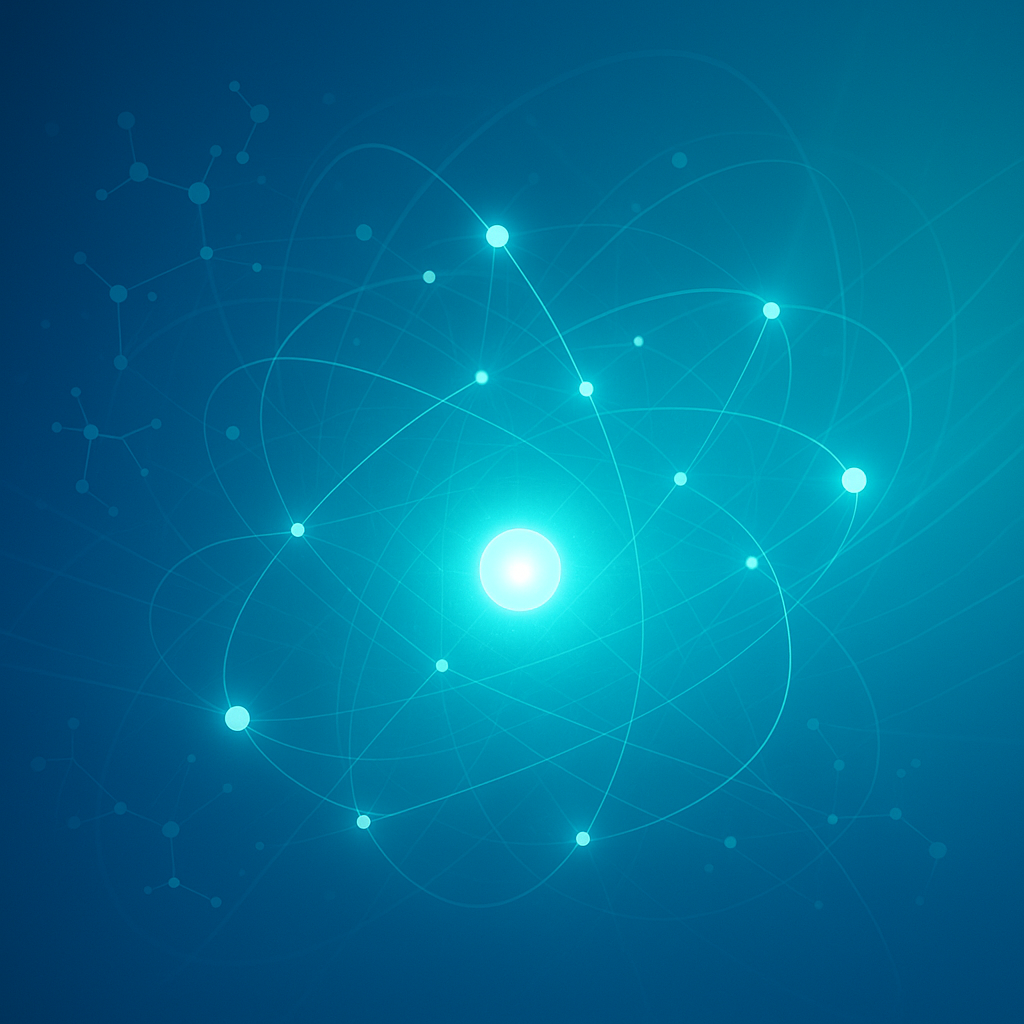

![hero image](hero_image.png)

Selected Research Brief: Becoming an AI engineer: step-by-step guide to skills, education, and career progression

Key Facts and Statistics:
• AI engineer job openings are growing 20–26% annually, with 143% year-over-year growth in some markets.  
• Median salaries by experience (US): entry $90K–160K, mid $140K–210K, senior $220K–500K+.  
• LinkedIn’s fastest-growing job in 2025–2026: AI Engineer.  
• Total compensation at top tech firms can reach $350K–550K+.

Main Themes and Arguments:
1. Role Definition  
  – AI engineers build real-world applications using pre-trained models (e.g., GPT-4).  
  – Distinct from ML engineers (train models) and data scientists (analyze data).  
  – Core tasks: model integration, AI agent creation, system performance optimization, deployment, and monitoring.

2. Skills and Education Path  
  – Programming: Python (3.10+), NumPy, Pandas, APIs.  
  – Math foundations: linear algebra, probability, statistics, calculus.  
  – ML basics: Scikit-learn; Deep learning: PyTorch or TensorFlow.  
  – Modern AI: prompt engineering, Retrieval-Augmented Generation (RAG), embeddings.  
  – MLOps & DevOps: Docker, Kubernetes, cloud (AWS/GCP/Azure).  
  – Systems & tools: LLM APIs, vector databases (Pinecone, Weaviate), Git, CI/CD.

3. Career Progression and Roadmap  
  – 8–12 month plan at 15–20 study hours/week:  
    • Months 1–3: Python, math, data handling, project structure.  
    • Months 4–6: Core ML algorithms, model evaluation, basic deployments.  
    • Months 7–9: Deep learning, LLM APIs, RAG architectures.  
    • Months 10–12: Portfolio projects, cloud deployments, monitoring, cost optimization.  
  – Specialize in AI software engineering, ML engineering, or reinforcement learning.

4. Industry Context  
  – AI powers search engines, healthcare, finance, autonomous vehicles.  
  – Employers demand production-ready AI systems, not just research prototypes.  
  – Full lifecycle management: design, development, deployment, scaling, and maintenance.

Notable Data Points:
• 12-month AI engineer roadmap is achievable with consistent effort.  
• Future job growth projected at 20–26% annually through 2033.  
• Cost optimization and reliability engineering for LLM-based systems are in high demand.

Source URLs:
• https://www.braincuber.com/tutorial/ai-engineer-roadmap-2026-complete-guide  
• https://everyonewhocode.com/ai-engineer-roadmap-2026-the-complete-step-by-step-guide-to-becoming-an-ai-engineer/  
• https://www.dataexpert.io/blog/ai-engineering-career-path-complete-guide-2026  
• https://www.thrivewithai.live/learn/ai-engineer-roadmap-2026  
• https://letsdatascience.com/blog/ai-engineer-roadmap-2026-skills-tools-and-career-path

In [50]:
from IPython.display import Image, display
import time

print(f"Agent: {result.last_agent.name}")
print(f"---")




# Forces display to reload from disk rather than browser cache
display(Image(filename='hero_image.png', data=open('hero_image.png', 'rb').read()))
clean_output = result.final_output.replace("sandbox:/", "")
display(Markdown(clean_output))


#### Test to generate an image of an apple and display it here in this notebook

2026-10-08 22:09:41,105 [INFO] Initializing OpenAI client...
2026-10-08 22:09:41,114 [INFO] Sending image generation request for prompt: 'A simple, crisp red apple on a plain white background'
2026-10-08 22:09:44,198 [INFO] HTTP Request: POST https://api.openai.com/v1/traces/ingest "HTTP/1.1 204 No Content"
2026-10-08 22:10:05,677 [INFO] HTTP Request: POST https://api.openai.com/v1/images/generations "HTTP/1.1 200 OK"
2026-10-08 22:10:05,903 [INFO] Received response from OpenAI API.
2026-10-08 22:10:05,905 [INFO]   ✅ Image Base64 payload retrieved successfully!

--- GENERATED IMAGE BASE64 DATA URI ---
data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAABAAAAAQACAIAAADwf7zUAABVNGNhQlgAAFU0anVtYgAAAB5qdW1kYz... (truncated)
---------------------------------------

2026-10-08 22:10:05,905 [INFO] Rendering image in notebook output...



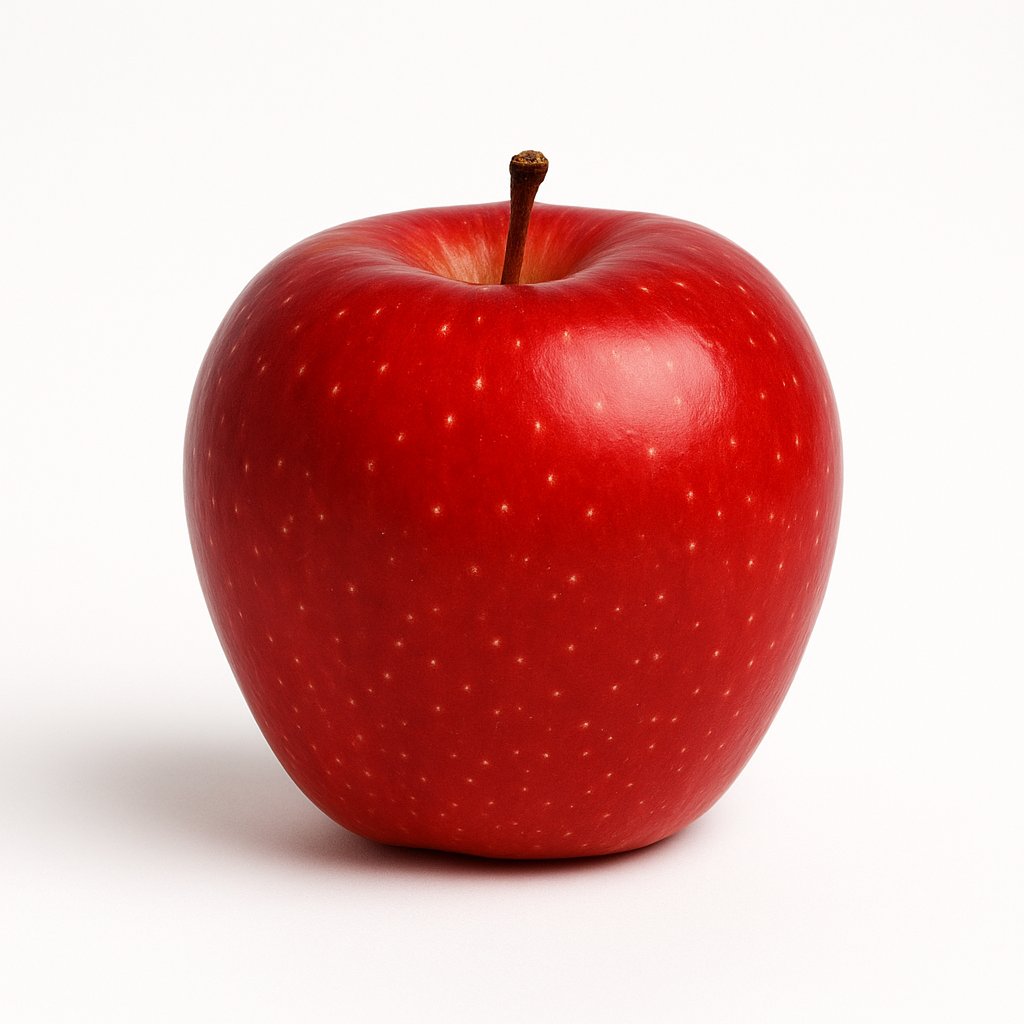

2026-10-08 22:10:05,917 [INFO] Image displayed successfully.


In [51]:
import base64
import logging
import os
import sys
from dotenv import load_dotenv
from IPython.display import Image, display
from openai import OpenAI

# 1. Configure logging to stdout so step-by-step progress appears in the cell
logging.basicConfig(
	level=logging.INFO,
	format="%(asctime)s [%(levelname)s] %(message)s",
	handlers=[logging.StreamHandler(sys.stdout)],
	force=True,  # Overrides any existing notebook logger configuration
)
logger = logging.getLogger("ImageTest")

# 2. Setup API key and OpenAI client
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
	logger.error("OPENAI_API_KEY is missing! Please check your .env file.")
else:
	logger.info("Initializing OpenAI client...")
	client = OpenAI(api_key=api_key)

	# 3. Define test prompt
	prompt = "A simple, crisp red apple on a plain white background"
	logger.info(f"Sending image generation request for prompt: '{prompt}'")

	try:
		# Call the live image generation API
		response = client.images.generate(
			model="gpt-image-1-mini",
			prompt=prompt,
			size="1024x1024",
			quality="high",
			n=1,
		)

		logger.info("Received response from OpenAI API.")
		item = response.data[0]
		image_uri = None

		# Check if an HTTP URL was returned
		if getattr(item, "url", None):
			image_uri = item.url
			logger.info("  ✅ Image URL retrieved successfully!")
			print(f"\n--- GENERATED IMAGE URL ---\n{image_uri}\n----------------------------\n")

		# Check if b64_json payload was returned instead
		elif getattr(item, "b64_json", None):
			image_uri = f"data:image/png;base64,{item.b64_json}"
			logger.info("  ✅ Image Base64 payload retrieved successfully!")
			print(f"\n--- GENERATED IMAGE BASE64 DATA URI ---\n{image_uri[:100]}... (truncated)\n---------------------------------------\n")

		else:
			logger.warning("Response payload contained neither 'url' nor 'b64_json'.")

		# 4. Render image directly in the notebook output
		if image_uri:
			logger.info("Rendering image in notebook output...")
			display(Image(url=image_uri))
			logger.info("Image displayed successfully.")

	except Exception as e:
		logger.error(f"Image generation failed with error: {e}", exc_info=True)

2026-10-08 22:10:05,934 [INFO] Initializing OpenAI client...
2026-10-08 22:10:05,935 [INFO] Sending image generation request for prompt: 'A clean, abstract, high-tech healthcare environment in 2040. Futuristic medical ...'
2026-10-08 22:10:33,180 [INFO] HTTP Request: POST https://api.openai.com/v1/images/generations "HTTP/1.1 200 OK"
2026-10-08 22:10:33,407 [INFO] Received response from OpenAI API.
2026-10-08 22:10:33,407 [INFO]   ✅ Base64 payload retrieved successfully!

--- GENERATED IMAGE DATA URI ---
data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAABAAAAAQACAIAAADwf7zUAABVNGNhQlgAAFU0anVtYgAAAB5qdW1kYz... (truncated)
---------------------------------

2026-10-08 22:10:33,408 [INFO] Rendering image in notebook output...



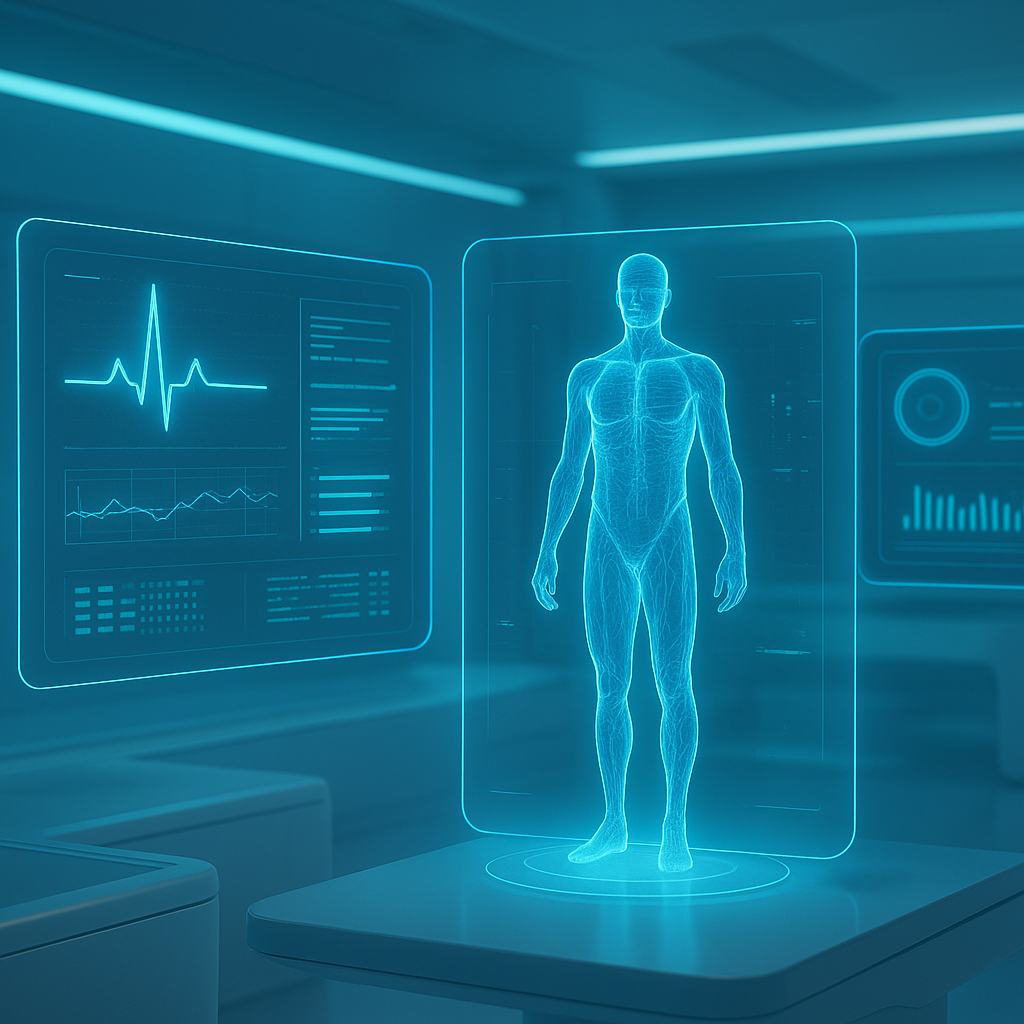

2026-10-08 22:10:33,421 [INFO] Image displayed successfully.


In [52]:
import base64
import logging
import os
import sys
from dotenv import load_dotenv
from IPython.display import Image, display
from openai import OpenAI

# 1. Configure logging to stdout so step-by-step progress appears in the cell
logging.basicConfig(
	level=logging.INFO,
	format="%(asctime)s [%(levelname)s] %(message)s",
	handlers=[logging.StreamHandler(sys.stdout)],
	force=True,  # Overrides any existing notebook logger configuration
)
logger = logging.getLogger("ImageTest")

# 2. Setup API key and OpenAI client
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
	logger.error("OPENAI_API_KEY is missing! Please check your .env file.")
else:
	logger.info("Initializing OpenAI client...")
	client = OpenAI(api_key=api_key)

	# 3. Define the futuristic healthcare prompt
	prompt = (
		"A clean, abstract, high-tech healthcare environment in 2040. "
		"Futuristic medical diagnostics interface, glowing digital data visualization, "
		"subtle holographic human body scan, blue and teal ambient lighting, "
		"sleek futuristic clinical aesthetic, soft depth of field."
	)
	logger.info(f"Sending image generation request for prompt: '{prompt[:80]}...'")

	try:
		# Call the live image generation API
		response = client.images.generate(
			model="gpt-image-1-mini",
			prompt=prompt,
			size="1024x1024",
			quality="high",
			n=1,
		)

		logger.info("Received response from OpenAI API.")
		item = response.data[0]
		image_uri = None

		# Check if Base64 payload was returned
		if getattr(item, "b64_json", None):
			image_uri = f"data:image/png;base64,{item.b64_json}"
			logger.info("  ✅ Base64 payload retrieved successfully!")
			print(f"\n--- GENERATED IMAGE DATA URI ---\n{image_uri[:100]}... (truncated)\n---------------------------------\n")

		# Fallback to HTTP URL if returned
		elif getattr(item, "url", None):
			image_uri = item.url
			logger.info("  ✅ Image URL retrieved successfully!")
			print(f"\n--- GENERATED IMAGE URL ---\n{image_uri}\n----------------------------\n")

		else:
			logger.warning("Response payload contained neither 'b64_json' nor 'url'.")

		# 4. Render image directly in the notebook output
		if image_uri:
			logger.info("Rendering image in notebook output...")
			display(Image(url=image_uri))
			logger.info("Image displayed successfully.")

	except Exception as e:
		logger.error(f"Image generation failed with error: {e}", exc_info=True)